# 📓 Cas d'usage IA — [Orientation et tri multimodal des demandeurs d'emploi]

**Auteur** : `Nicolas EVRARD`  
**Promo** : ATOS Atlas IA — Parcours 2 (Pros IT) — Groupe 2 
**Date début** : `10/07/2026`  
**Dernière mise à jour** : `10/07/2026`

---

## 0. Imports & configuration

In [1]:
# Imports standards
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sys
import subprocess
from datetime import datetime
from pathlib import Path

# Reproductibilité
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
sys.path.insert(0, "..")  # rend src/ importable depuis notebooks/

# Affichage
pd.set_option("display.max_columns", 50)
sns.set_theme(style="whitegrid")


# Rechargement automatique des fichiers dans jupyter lors du lancement des fonctions si ces derniers ont été modifiés. 
%load_ext autoreload
%autoreload 2
    
# Scripts outillage
from src.data_loading import charger_donnees, identification
from src.eda import profiler, detecter_valeurs_aberrantes, validation_mae, validation_mediane_globale 

# Imports ML (à activer au fur et à mesure)
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.metrics import (
    mean_absolute_error,
    median_absolute_error,
    mean_squared_error
)
# from sklearn.preprocessing import StandardScaler, OneHotEncoder
# from sklearn.compose import ColumnTransformer
# from sklearn.pipeline import Pipeline

## 0.5 Traçabilité de la session

In [2]:
# --- Métadonnées du dataset ---
DATASET_NAME = "Sujet Examen CISIA - Promo Upskilling Atlas - mai-oct2026.csv"
DATASET_SOURCE = "data/dataset_trajectoire_emploi_Sujet Examen CISIA - Promo Upskilling Atlas - mai-oct2026 (Session-00279143).csv"        # URL, chemin, ou contact si fourni par le client
DATASET_VERSION = "YYYY-MM-DD"  # date d'extraction OU version explicite
DATASET_SHA1 = "62c207b2eac847bd0fec6ee54a50845f4a324f70"  #


# --- Métadonnées de la session ---
session_date = datetime.now().isoformat(timespec="minutes")
py_version = sys.version.split()[0]

try:
    git_commit = subprocess.check_output(
        ["git", "rev-parse", "--short", "HEAD"], stderr=subprocess.DEVNULL
    ).decode().strip()
except (subprocess.CalledProcessError, FileNotFoundError):
    git_commit = "non disponible (notebook hors repo Git)"

print(f"Date session : {session_date}")
print(f"Python       : {py_version}")
print(f"NumPy        : {np.__version__}")
print(f"Pandas       : {pd.__version__}")
print(f"Git commit   : {git_commit}")
print(f"Dataset      : {DATASET_NAME} (source={DATASET_SOURCE}, version={DATASET_VERSION})")

Date session : 2026-08-05T17:12
Python       : 3.13.13
NumPy        : 2.4.4
Pandas       : 2.3.3
Git commit   : 40284b3
Dataset      : Sujet Examen CISIA - Promo Upskilling Atlas - mai-oct2026.csv (source=data/dataset_trajectoire_emploi_Sujet Examen CISIA - Promo Upskilling Atlas - mai-oct2026 (Session-00279143).csv, version=YYYY-MM-DD)


In [3]:
df = charger_donnees()
display(df.head(5))

Chargement du CSV : /home/a131270/workspace/briefs/m9/data/dataset_trajectoire_emploi_Sujet Examen CISIA - Promo Upskilling Atlas - mai-oct2026 (Session-00279143).csv


,usager_id,age,niveau_diplome,anciennete_poste_ans,code_rome_vise,code_insee_commune,est_allocataire,nationalite_hors_ue,synthese_entretien,classe_retour_emploi
0,ID_0000,56.0,Bac+2,2.6,D1503,18273,1.0,0,Compétences à réactualiser sur les outils numé...,1
1,ID_0001,46.0,Sans diplôme,10.5,G1302,07240,0.0,0,Cumul de difficultés. Pas de moyen de transpor...,2
2,ID_0002,NaN,Bac,1.4,M1705,01405,NaN,0,Compétences à réactualiser sur les outils numé...,0
3,ID_0003,60.0,Bac,0.2,A1203,63359,1.0,0,Problème ponctuel de mobilité géographique. Zo...,1
4,ID_0004,25.0,Sans diplôme,1.2,N1301,21302,1.0,0,Projet de reconversion à affiner. Besoin d'une...,0


---
## 1. Cadrage métier & problème

### 1.1 Contexte client

Le client est l'**agence nationale de l’emploi** chargée d’accompagner **les demandeurs d’emploi** et d’adapter les parcours de suivi à leur situation. Son activité repose sur l’analyse de nombreuses informations administratives, socio-professionnelles, géographiques et textuelles recueillies lors des entretiens. Le problème métier consiste à ***identifier rapidement*** les usagers susceptibles de retrouver un emploi à court terme, à moyen terme ou présentant un risque de chômage de longue durée. Une mauvaise orientation peut conduire à un accompagnement inadapté et à une perte de chance pour l’usager. Le recours à l’intelligence artificielle vise donc à fournir **aux conseillers** un outil d’aide à la décision capable d’analyser simultanément des données tabulaires et des synthèses textuelles. L’objectif est d’améliorer la rapidité, la cohérence et la fiabilité de **classification**, tout en maintenant une validation humaine et en respectant les contraintes éthiques et réglementaires.


### 1.2 Énoncé du problème IA

La tâche d’intelligence artificielle consiste à prédire le _délai potentiel de retour à l’emploi d’un demandeur_ à partir de données tabulaires, catégorielles et textuelles. Il s’agit d’un problème de **classification à 3 classes**. L'intelligence artificielle devra classer chaque demandeur selon trois catégories :
- `classe 0` ==> **retour rapide** en moins de 6 mois
- `classe 1` ==> **retour moyen** entre 6 et 12 mois
- `classe 2` ==> **risque de longue durée** au-delà de 12 mois.


### 1.3 Bénéficiaires & impacts

Les utilisateurs directs de la solution sont **les conseillers de l’agence nationale de l’emploi**, qui s’appuient sur la prédiction pour orienter les usagers vers un niveau d’accompagnement adapté. Les responsables d’agence, les équipes métier, les équipes de pilotage, le ministère du travail peuvent également utiliser les résultats agrégés pour suivre les parcours et ajuster les ressources disponibles.

Les personnes indirectement concernées sont principalement **les demandeurs d’emploi**, car la prédiction peut influencer l’intensité de leur accompagnement, l’accès à certaines formations ou la priorité accordée à leur dossier. Une erreur de classification peut donc entraîner un suivi insuffisant, une orientation inadaptée ou une perte de chance. L’administration publique est aussi concernée, puisqu’elle assume la responsabilité de l’usage du système et de ses conséquences.


### 1.4 Critères de succès



| ID | Type | Critère | Cible initiale (client) | Justification | Cible révisée après EDA | Justification de la révision |
|---|---|---|---|---|---|---|
| `C1` |Métier|Limiter les erreurs critiques où un usager de `classe 2` est prédit en `classe 0` ou `classe 1` (Précision/Rappel => PR_AUC) | Rappel `classe 0` et `classe 1`> 95% et la précision de la` classe 2` > 95% | Ces erreurs de classification représente **le risque le plus important** car il y a un impact humain et financier derrière. L'accompagnement ne sera pas adapté pour le demandeur et ce dernier se retrouvera dans une situation d'échec pour une longue période (risque de démotivation accrue et perte de confiance). Ce temps perdu jouera malheureusement contre le demandeur d'emploi qui le positionnera dans une situation irreversible si une ré évaluation de son cas n'est pas établie. | - | - |
| `C2` |Modèle|F1-score macro sur les trois classes|F1 macro ≥ 0,75| Il s'agit d'un besoin opérationnel, on part sur une target simple | - | - |
| `C3` |Opérationnel|Temps de réponse de l’API pour une prédiction|Temps de réponse < 200 ms| Il s'agit d'un besoin opérationnel, on part sur une target simple | - | - |

### 1.5 Risques éthiques & réglementaires anticipés

Pour rappel, l’objectif de ce système d’intelligence artificielle est de fournir aux conseillers un outil d’aide à la classification des demandeurs d’emploi selon trois catégories de délai de retour à l’emploi : rapide, moyen ou long. Cette classification doit permettre d’adapter les mesures d’accompagnement proposées à chaque usager dans le cadre de sa recherche d’emploi.

Les données utilisées pour entraîner le modèle proviennent directement des demandeurs d’emploi et constituent, à ce titre, des données à caractère personnel. Le principal cadre réglementaire applicable au projet est donc le règlement général sur la protection des données, ou **RGPD**, correspondant au règlement européen (UE) 2016/679.

Au sens de l’article 4 du RGPD, ce cas d’usage peut être qualifié de _profilage_, puisqu’il repose sur un traitement automatisé de données personnelles visant à évaluer certains aspects de la situation d’une personne et à prédire son délai potentiel de retour à l’emploi.

Le tableau ci-dessous présente les principales références réglementaires applicables, les risques identifiés, leurs conséquences possibles ainsi que les mesures de prévention envisagées.


| Réf Réglementaire | Risque identifié | Conséquences possibles | Mesures de prévention envisagées |
|---|---|---|---|
| Article 6.1 - Licéité du traitement  | **Utilisation de données personnelles** | Les variables `usager_id`, '`age`, `niveau_diplome`, `anciennete_poste_ans`, `code_rome_vise`, `code_insee_commune`, `est_allocataire`, `nationalite_hors_ue`, `synthese_entretien` et `classe_retour_emploi` sont des données personnelles. L'usage de ces dernières sont licites si elles valident une condition de l'article 6.1 | S'assurer que le processus de profilage est réalisé avec un consentement du demandeur d'emploi pour les données déjà récupérées et celles à venir. |
| Article 9 - Traitement portant sur des catégories particulières  | **Utilisation de données personnelles sensibles** | Les variables `synthese_entretien` et `nationalite_hors_ue` peuvent influencer directement la prédiction et créer un risque de discrimination dans l’orientation des usagers. | Retirer ces variables du modèle utilisé en production. Elles peuvent éventuellement être conservées dans un jeu de données séparé afin de mesurer les écarts de performance entre groupes. |
| Article 9 - Traitement portant sur des catégories particulières  | **Présence de données sensibles dans le texte libre** | La synthèse d’entretien (`synthese_entretien`) peut contenir des informations relatives à la santé, à l’origine, à la situation familiale ou à d’autres éléments privés non prévus dans les colonnes structurées. | Encadrer la saisie des conseillers, anonymiser ou détecter les données sensibles et éviter de conserver les textes complets dans les journaux techniques. |
| RGPD Article 13 - Informations à fournir<br> RGPD Article 21 - Droit d'opposition | **Absence de consentement ou d’information** | Les usagers peuvent ne pas avoir été correctement informés de l’utilisation de leurs données pour entraîner ou exploiter un modèle d’intelligence artificielle. | Fournir une information claire sur les finalités du traitement, les données utilisées, les destinataires, la durée de conservation et les droits des personnes, ainsi que la possibilité au demandeur de refuser cette collecte. |
| RGPD Article 15 - Droit d'accès de la personne concernée<br>RGPD Article 16 - Droit de rectification<br>Article 21 - Droit d'opposition | **Difficulté d’exercice des droits RGPD** | Un usager peut rencontrer des difficultés pour accéder à ses données, demander leur rectification ou contester une décision assistée par l’algorithme. | Mettre en place une procédure permettant l’exercice des droits d’accès, de rectification, d’opposition et de contestation, ainsi qu’une intervention humaine. |
| RGPD Article Article 17 - Droit à l'effacement | **Difficulté retirer les données** | Un usager peut rencontrer des difficultés pour supprimer ses données personnelles des lors que ce dernier est entré dans le processus d'apprentissage et que le model soit déployé en production. | Ajouter une feature dans le dataset de données nommée `date_peremption` qui sera renseigné à defaut lors de la saisie et corrigée à la discretion de l'usager. Il faudra alors **imposer** des cycles de purge du dataset global |
| RGPD Article 22 Décision individuelle automatisée | **Automatisation excessive de la décision** | Le conseiller peut accorder une confiance excessive au résultat du modèle et ne pas suffisamment analyser la situation individuelle de l’usager. | Présenter le système comme un outil d’aide à la décision. La prédiction doit pouvoir être modifiée ou refusée par le conseiller, qui conserve la responsabilité de l’orientation finale. |
| RGPD Article 23 - Limitations | **Conservation excessive des données** | Les données personnelles, les prédictions et les historiques peuvent être conservés plus longtemps que nécessaire. | Définir une politique de conservation et de suppression automatique adaptée aux finalités métier, réglementaires et techniques. |
| Charte des droits fondamentaux de l’UE, article 21 | **Biais et discrimination algorithmique** | Certaines variables comme l’age, la nationalité hors UE, le lieu de résidence ou le niveau de diplôme peuvent entraîner des écarts de traitement entre les usagers. Les synthèses rédigées par les conseillers peuvent également contenir des biais implicites ou des stéréotypes. | Comparer les performances du modèle entre différents groupes, mesurer les écarts de rappel et de taux d’erreur, tester un scénario sans variables sensibles et privilégier ce scénario si la perte de performance reste acceptable. |
| TODO | **Erreur critique de classification** | Un usager réellement en `classe 2`, mais prédit en `classe 0` ou `classe 1`, risque de ne pas recevoir l’accompagnement renforcé nécessaire. Cette erreur peut provoquer une perte de chance pour l’usager. | Utiliser des poids de classes, une fonction de coût asymétrique ou des seuils de décision adaptés. Suivre spécifiquement le nombre et le taux d’erreurs `2 → 0 ou 1`. |
| TODO | **Dérive du modèle dans le temps** | Les évolutions du marché de l’emploi, des politiques publiques ou des pratiques des conseillers peuvent dégrader les performances du modèle ou augmenter les biais. | Monitorer la distribution des données, les performances globales, les erreurs critiques et les écarts entre groupes. Déclencher un réentraînement contrôlé lorsque cela est nécessaire. |

### 1.6 📝 Synthèse cadrage

L’agence nationale de l’emploi souhaite utiliser une IA multimodale pour **classer les demandeurs d’emploi** selon trois délais de retour à l’emploi et adapter leur accompagnement. La solution doit assister les conseillers tout en limitant les erreurs critiques, notamment _la sous-estimation des situations à risque de chômage de longue durée_. Son déploiement doit enfin respecter **le RGPD**, prévenir les discriminations, garantir l’intervention humaine et assurer la traçabilité des décisions.

---
## 2. Identification & acquisition des données

In [4]:
#  Lecture du nombre de features et de lignes
display(df.shape)

(2500, 10)

### 2.1 Sources

| Source | Type | Volumétrie | Format | Accès | Date extraction | nb features (hors cible) |
|---|---|---|---|---|---|---|
| Echantillons d'Informations métier collectées par les conseillers| tabulaire et textuelle | 2500 | csv | lecture | `15/07/2026` | 9 |


### 2.2 Dictionnaire de variables

In [5]:
# 2.2.1 Première affichage pour lecture
display(df.head(5))

# 2.2.2 Identification des données permettant de visualité la structure des donneés.
display (identification(df))

# 2.2.3 Affichage des categories pour features suspicieuses niveau_diplome, synthese_entretien
display (df["niveau_diplome"].unique())
display (df["synthese_entretien"].unique())

,usager_id,age,niveau_diplome,anciennete_poste_ans,code_rome_vise,code_insee_commune,est_allocataire,nationalite_hors_ue,synthese_entretien,classe_retour_emploi
0,ID_0000,56.0,Bac+2,2.6,D1503,18273,1.0,0,Compétences à réactualiser sur les outils numé...,1
1,ID_0001,46.0,Sans diplôme,10.5,G1302,07240,0.0,0,Cumul de difficultés. Pas de moyen de transpor...,2
2,ID_0002,NaN,Bac,1.4,M1705,01405,NaN,0,Compétences à réactualiser sur les outils numé...,0
3,ID_0003,60.0,Bac,0.2,A1203,63359,1.0,0,Problème ponctuel de mobilité géographique. Zo...,1
4,ID_0004,25.0,Sans diplôme,1.2,N1301,21302,1.0,0,Projet de reconversion à affiner. Besoin d'une...,0


,Feature,Type,Cardinalité,Minimum,Maximum
0,usager_id,object,2500,ID_0000,ID_2499
1,age,float64,46,18.0,63.0
2,niveau_diplome,object,4,Non applicable,Non applicable
3,anciennete_poste_ans,float64,154,0.0,22.6
4,code_rome_vise,object,50,A1202,W1401
5,code_insee_commune,object,2407,01007,97601
6,est_allocataire,float64,2,0.0,1.0
7,nationalite_hors_ue,int64,2,0,1
8,synthese_entretien,object,9,Non applicable,Non applicable
9,classe_retour_emploi,int64,3,0,2


array(['Bac+2', 'Sans diplôme', 'Bac', 'Bac+5', nan], dtype=object)

array(['Compétences à réactualiser sur les outils numériques. Motivation correcte.',
       "Cumul de difficultés. Pas de moyen de transport et garde d'enfants complexe.",
       'Problème ponctuel de mobilité géographique. Zone mal desservie.',
       "Projet de reconversion à affiner. Besoin d'une formation complémentaire.",
       'Excellente présentation, compétences techniques à jour. Reprise rapide visée.',
       'Candidat très dynamique, mobilité nationale validée. Projet clair.',
       "Perte de confiance importante. Risque d'exclusion, barrière de la langue.",
       "Freins périphériques majeurs. Situation d'illettrisme numérique constatée.",
       'Profil autonome, recherche active, aucun frein périphérique identifié.',
       nan], dtype=object)

| Variable | Description | Type | Plage / valeurs | Donnée perso. ? | Sensible (Art. 9 RGPD)? | Discriminatoire ? | Cible ? |
|---|---|---|---|:---:|:---:|:---:|:---:|
| `usager_id` | Identifiant unique du demandeur d'emploi | Identifiant | Identifiant utilisateur, pas de relation entre les ids | ✅ | ❌ | ❌ | ❌ |
| `age` | Âge de l'usager en années | Numérique discrète | min = 18.0 et max = 63.0</br> | ✅ | ❌ | ✅ | ❌ |
| `niveau_diplome` | Plus haut niveau de diplôme obtenu | Catégorielle ordinale | • Sans diplôme</br>• Bac</br>• Bac+2</br>• Bac+5 | ✅ | ❌ | ⚠️ Risque indirect combiné avec `anciennete_poste_ans` pourrait retrouver l'`age` | ❌ |
| `anciennete_poste_ans` | Nombre d'années d'expérience dans le dernier emploi occupé | Numérique continue | min = 0.0 et max = 22.6 | ✅ | ❌ | ⚠️ Risque indirect combiné avec `niveau_diplome` pourrait retrouver l'`age` | ❌ |
| `code_rome_vise` | Code à 5 caractères du Répertoire Opérationnel des Métiers et des Emplois ciblé par l'usager | Catégorielle nominale | Identifiant métier sans relations entre les codes<br>50 codes présents dans le dataset | ✅ | ❌ | ❌ | ❌ |
| `code_insee_commune` | Code officiel géographique INSEE de la commune de résidence | Catégorielle nominale | Identifiant géographique, pas de relations entre les codes<br>**2 407** codes présents dans le dataset| ✅ | ❌ | ✅ | ❌ |
| `est_allocataire` | Statut d'indemnisation de l'usager | Binaire | • 0 (Non)<br>• 1 (Oui)<br> | ✅ | ❌ | ✅ | ❌ |
| `nationalite_hors_ue` | Classification de la nationnalité du demandeur d'emploi | Binaire | • 0 (Nationalité UE)<br>• 1 (Nationalité hors Union Européenne) | ✅ | ❌ | ✅ | ❌ |
| `synthese_entretien` | Texte libre contenant les notes textuelles du conseiller lors de l'entretien | Textuelle</br> (cardinalité de **9** cf. §2) | Texte libre semblant suivre une classification en 9 categories | ✅ | ❌ dans les valeurs observées, mais potentiellement oui en production | ✅ | ❌ |
| `classe_retour_emploi` | Temps nécessaire au retour à l'emploi | Catégorielle ordinale | • 0 (Rapide < 6m)<br>• 1 (Moyen 6-12m)<br>• 2 (Risque de longue durée > 12m) | ✅ | ❌ | ❌ | ✅ |

### 2.3 📝 Synthèse acquisition

Le jeu de données composé de données collectées au sein d'une agence nationale de l'emploi. Il contient 2 500 observations, neuf variables explicatives et une variable cible. Toutes les informations rattachées à `usager_id` constituent des données à caractère personnel. Aucune variable structurée ne relève explicitement des catégories particulières de l’article 9 du RGPD, mais `synthese_entretien` pourrait à l'avenir contenir des données sensibles. Les variables `nationalite_hors_ue`, `age`, `niveau_diplome`, `niveau_diplome`, `synthese_entretien`, `est_allocataire` et `code_insee_commune` présentent par ailleurs un risque discriminatoire direct ou indirect qui devra être évalué lors de la comparaison des scénarios.

## 3. Exploration & analyse des données (EDA)

Afin d'évaluer les performances du modèle d'IA, **4 scénarios** sont établis : 

- **`Scénario 1`** — Approche multimodale complète : Utilisation de l'intégralité des variables (tabulaires + texte vectorisé). 
- **`Scénario 2`** — Sans variables sensibles (Approche Éthique) : Retrait des variables considérées comme éthiquement sensibles avec justification argumentée au sens de la CNIL et du RGPD. 
- **`Scénario 3`** — Diagnostic par le texte seul (NLP pure) : Prédiction basée exclusivement sur la synthèse écrite de l'entretien de cadrage pour tester la robustesse du modèle de langage face à des verbatims contenant du bruit stochastique. 
- **`Scénario 4`** — Données contextuelles pures (Tabulaire seul) : Prédicteur basé uniquement sur l'âge, les diplômes, l'ancienneté et la géographie, sans l'apport du contexte sémantique textuel. 

Cette approche multi-scénario est à prendre en compte dans l'analyse de données des features notament pour la partie **imputation**.

### 3.1 Premier coup d'œil
#### 3.1.1 Profiling cardinalité, manquants, abberation et doublons

In [6]:
## 3.1 Premier coup d'œil
df.head()
df.info()
df.describe(include="all")

display(profiler(df))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 10 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   usager_id             2500 non-null   object 
 1   age                   2378 non-null   float64
 2   niveau_diplome        2416 non-null   object 
 3   anciennete_poste_ans  2500 non-null   float64
 4   code_rome_vise        2500 non-null   object 
 5   code_insee_commune    2500 non-null   object 
 6   est_allocataire       2456 non-null   float64
 7   nationalite_hors_ue   2500 non-null   int64  
 8   synthese_entretien    2419 non-null   object 
 9   classe_retour_emploi  2500 non-null   int64  
dtypes: float64(3), int64(2), object(5)
memory usage: 195.4+ KB


,Feature,Type,Cardinalité,Valeurs manquantes,IQR,Valeurs aberrantes selon l'IQR,Valeurs dupliquées
0,usager_id,object,2500,0,N/A,N/A,0
1,age,float64,47,122,23.0,0,2453
2,niveau_diplome,object,5,84,N/A,N/A,2495
3,anciennete_poste_ans,float64,154,0,3.3,126,2346
4,code_rome_vise,object,50,0,N/A,N/A,2450
5,code_insee_commune,object,2407,0,N/A,N/A,93
6,est_allocataire,float64,3,44,1.0,0,2497
7,nationalite_hors_ue,int64,2,0,0.0,295,2498
8,synthese_entretien,object,10,81,N/A,N/A,2490
9,classe_retour_emploi,int64,3,0,1.0,0,2497


#### 3.1.2 Séparation des jeux de données Train / Test

Etape importante pour éviter toute fuite de données.

In [7]:
X = df.drop(columns=["classe_retour_emploi"])
y = df["classe_retour_emploi"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20, # Répartition 20 / 80
    random_state=42, # reproductible
    stratify=y # equité dans la distribution
)

df_train = X_train.copy()

### 3.2 Analyse des données - feature `usager_id`

La variable `usager_id` correspond à l’**identifiant unique** du demandeur d’emploi. Elle ne contient aucune information métier utile à la prédiction du délai de retour à l’emploi. Sa forte cardinalité (2500) pourrait conduire le modèle à mémoriser les observations du jeu d’entraînement plutôt qu’à apprendre des relations généralisables. Elle sera donc exclue des variables explicatives dans l’ensemble des scénarios.

Actions préconisés :

| feature | **`Scénario 1`** | **`Scénario 2`** | **`Scénario 3`** | **`Scénario 4`** |
|:---:|:---:|:---:|:---:|:---:|
|`usager_id`|❌ écartée|❌ écartée|❌ écartée|❌ écartée|

### 3.3 Analyse des données - feature `age`

La variable `age` correspond à l'age du demandeur d’emploi. On note 2 points importants dans le premier coup d'oeil (cf. $3.1) :
- Il y a des données manquantes. Il faudra mettre en place une stratégie d'imputation pour les valeurs manquantes.
- IQR étant élevée, il est nécessaire de voir la distribution des données pour établir une stratégie viable.

Effectif minimum : 25
Âge concerné : 44.0
Effectif maximum : 56
Âge concerné : 43.0
Effectif maximum : 100
Âge concerné : NaN


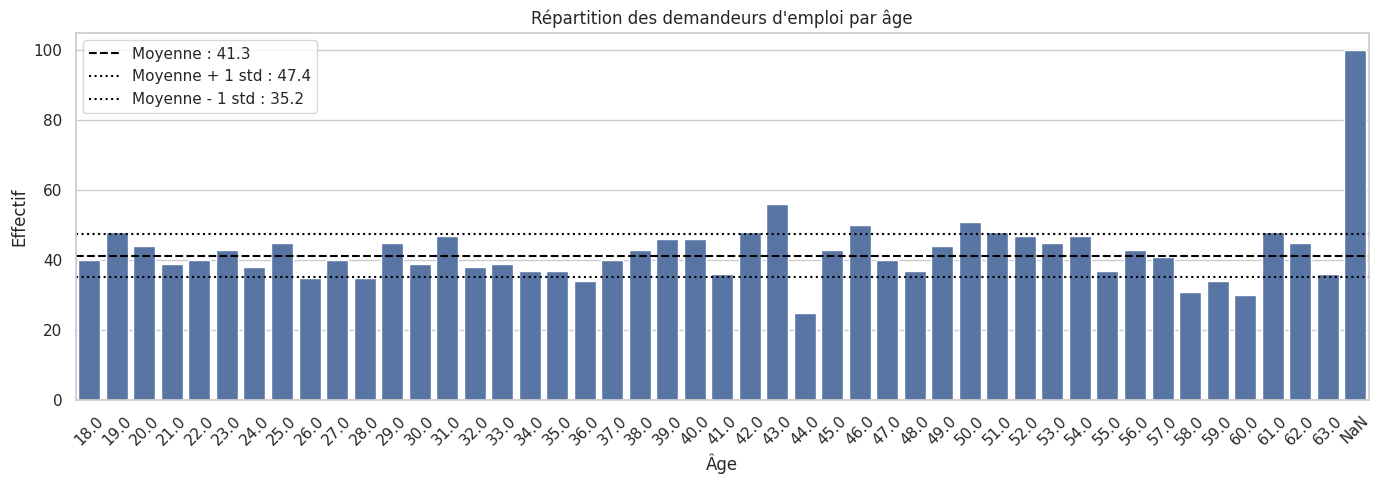

In [8]:
# Transformer les âges en libellés et les NaN en catégorie
age_affichage = df_train["age"].apply(
    lambda valeur: "NaN" if pd.isna(valeur) else str(valeur)
)

# Ordre d'affichage : âges croissants puis NaN
ordre = [
    str(age)
    for age in sorted(df["age"].dropna().unique())
] + ["NaN"]

# Effectif de chaque âge, NaN compris
effectifs = (
    age_affichage
    .value_counts()
    .reindex(ordre, fill_value=0)
)

# Moyenne des effectifs par modalité
effectif_moyen = effectifs.drop("NaN").mean()
ecart_type = effectifs.drop("NaN").std()

plt.figure(figsize=(14, 5))

ax = sns.countplot(
    x=age_affichage,
    order=ordre
)

ax.axhline(
    effectif_moyen,
    color="black",
    linestyle="--",
    label=f"Moyenne : {effectif_moyen:.1f}"
)

ax.axhline(
    effectif_moyen + ecart_type,
    color="black",
    linestyle=":",
    label=f"Moyenne + 1 std : {effectif_moyen + ecart_type:.1f}"
)

ax.axhline(
    max(0, effectif_moyen - ecart_type),
    color="black",
    linestyle=":",
    label=f"Moyenne - 1 std : {max(0, effectif_moyen - ecart_type):.1f}"
)

print("Effectif minimum :", effectifs.drop("NaN").min())
print("Âge concerné :", effectifs.drop("NaN").idxmin())
print("Effectif maximum :", effectifs.drop("NaN").max())
print("Âge concerné :", effectifs.drop("NaN").idxmax())
print("Effectif maximum :", effectifs.max())
print("Âge concerné :", effectifs.idxmax())

plt.title("Répartition des demandeurs d'emploi par âge")
plt.xlabel("Âge")
plt.ylabel("Effectif")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

A la première lecture on ne constate :
- Il n'y a pas de valeurs abbérantes sur l'axe des abscisses.
- La moyenne des effectifs (hors NaN) se situe à 51.7 avec ecart type de 44.5 - 58.9.
 - 3 catégories au dessus 47.4 (Max => 56 demandeurs agé 43 ans)
 - 4 catégories en dessous de 35.2 (Min => 25 demandeurs agé 44 ans)
 - La catégorie 'NaN' represente a elle seule **100 demandeurs**.

Hormis la catégorie 'Nan', les données 'age' sont plutôt équilibrées, la problématique va venir sur la stratégie d'imputation de la catégorie 'Nan' (effectif = 100) qui represente à elle seule 100/41.3 = **2.42 fois** la moyenne. Choisir une imputation de la mediane des ages n'est pas la bonne option car elle va desequilibrer la répartition vers la médiane globale.

#### 3.3.1 Approche sur l'imputation des données pour l'`age` à partir `anciennete_poste_ans` et `niveau_diplome`

Pour imputer les données d'`age` du demandeur, nous pouvons nous appuyer sur les deux features :  `anciennete_poste_ans` et `niveau_diplome` (cf. 2.2 réflexion faite sur le dictionanire). En effet, par similarité des profils (niveau_diplome et anciennete_postes_ans) nous pouvons réaliser la médiane par groupe et l'imputer pour les ages manquants. Je propose que nous équilibrions les catégories anciennete_postes_ans en 3, 4 et 5 categories :

In [9]:
# Copie des données pour travailler sur la categorie anciennete_poste_ans
df_anciennete_poste_ans = df_train.copy()

resultats_decoupage = []

# Boucle sur les 3 propositions (3, 4 ou 5 categories)
for i in range(3, 6):

    # Calcule des tranches en % => 33%, 25% ou 20%
    tranches = pd.qcut(
        df_anciennete_poste_ans["anciennete_poste_ans"],
        q=i
    )

    effectifs = tranches.dropna().value_counts(sort=False)

    # Calcule de la moyenne et des écarts types
    moyenne = effectifs.mean()
    ecart_type = effectifs.std()
    coefficient_variation = ecart_type / moyenne * 100

    print(f"\n--- Découpage en {i} catégories ---")
    display(effectifs)

    resultats_decoupage.append({
        "Nombre de catégories": i,
        "Effectif minimum": effectifs.min(),
        "Effectif maximum": effectifs.max(),
        "Effectif moyen": round(moyenne, 2),
        "Écart-type": round(ecart_type, 2),
        "Coefficient de variation (%)": round(
            coefficient_variation,
            2
        )
    })

display(pd.DataFrame(resultats_decoupage))


--- Découpage en 3 catégories ---


anciennete_poste_ans
(-0.001, 1.2]    685
(1.2, 3.2]       650
(3.2, 22.6]      665
Name: count, dtype: int64


--- Découpage en 4 catégories ---


anciennete_poste_ans
(-0.001, 0.8]    503
(0.8, 2.1]       529
(2.1, 4.1]       471
(4.1, 22.6]      497
Name: count, dtype: int64


--- Découpage en 5 catégories ---


anciennete_poste_ans
(-0.001, 0.6]    405
(0.6, 1.5]       414
(1.5, 2.7]       400
(2.7, 4.8]       388
(4.8, 22.6]      393
Name: count, dtype: int64

,Nombre de catégories,Effectif minimum,Effectif maximum,Effectif moyen,Écart-type,Coefficient de variation (%)
0,3,650,685,666.67,17.56,2.63
1,4,471,529,500.00,23.80,4.76
2,5,388,414,400.00,10.17,2.54


Finalement de découpage en **5 catégories** est celle qui présente le moins d'écart-type et de variation :
- "0-0.6 an",
- "0.6-1.5 ans",
- "1.5-2.7 ans",
- "2.7-4.8 ans",
- "4.8 ans et plus"

regardons la répartition en fonction sur une graphique et comparons là avec le précédent graphique :

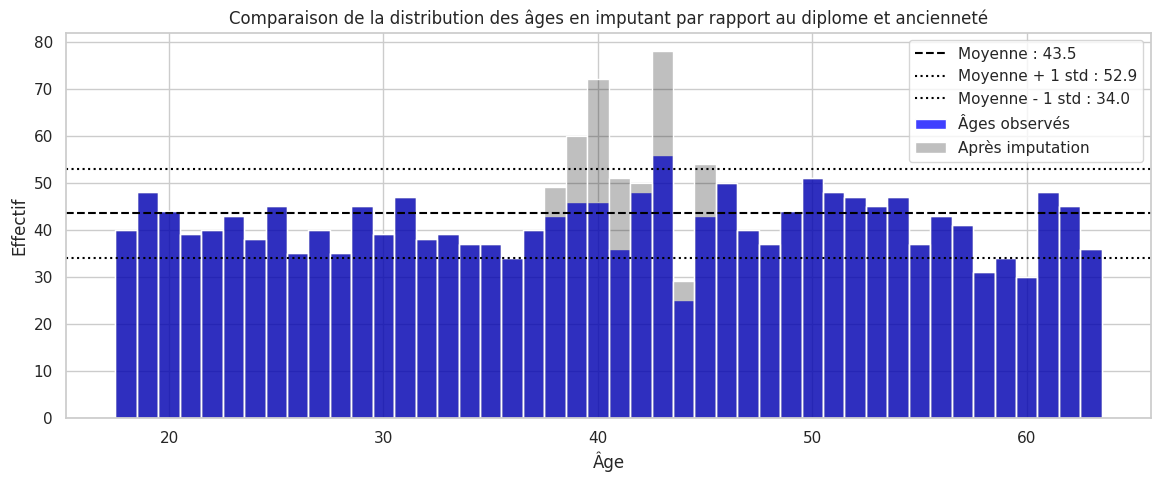

,age,age_impute,niveau_diplome,tranche_anciennete


NaN après Imputation : 0


In [10]:
# Copie de travail
df_age = df_train.copy()

# Classification en 4 catégories de la feature tranche_anciennete cf. §3.3.1
df_age["tranche_anciennete"] = pd.cut(
    df_age["anciennete_poste_ans"],
    bins=[-1, 0.6, 1.5, 2.7, 4.8, float("inf")], # Je laisse volontairement infini car l'age de la retraite reculent tous les ans.
    labels=[
     "0-0.6 an",
     "0.6-1.5 ans",
     "1.5-2.7 ans",
     "2.7-4.8 ans",
     "4.8 ans et plus"
    ]
)

# Recopie des données
df_age["age_impute"] = df_age["age"]

# Calcul de la médian par rapport au groupement niveau de diplome et tranche_anciennete
mediane_groupe_1 = df_age.groupby(
    [
       "niveau_diplome",
        "tranche_anciennete"
    ],
    dropna=False,
    observed=True 
)["age"].transform(
    lambda serie: serie.quantile(
        0.5,
        interpolation="nearest"
    )
)

# Imputation des ages 'NaN'
df_age["age_impute"] = df_age["age_impute"].fillna(
    mediane_groupe_1
)

plt.figure(figsize=(14, 5))

ax = sns.histplot(
    df_age["age"].dropna(),
    color='Blue',
    discrete=True,
    label="Âges observés",
    alpha=0.75
)

sns.histplot(
    df_age["age_impute"],
    color='Black',
    discrete=True,
    label="Après imputation",
    alpha=0.25
)

# Moyenne des effectifs par modalité
effectifs = (
    df_age["age_impute"]
    .dropna()
    .value_counts()
)

effectif_moyen = effectifs.mean()
ecart_type = effectifs.std()

ax.axhline(
    effectif_moyen,
    color="black",
    linestyle="--",
    label=f"Moyenne : {effectif_moyen:.1f}"
)

ax.axhline(
    effectif_moyen + ecart_type,
    color="black",
    linestyle=":",
    label=f"Moyenne + 1 std : {effectif_moyen + ecart_type:.1f}"
)

ax.axhline(
    max(0, effectif_moyen - ecart_type),
    color="black",
    linestyle=":",
    label=f"Moyenne - 1 std : {max(0, effectif_moyen - ecart_type):.1f}"
)


plt.title("Comparaison de la distribution des âges en imputant par rapport au diplome et ancienneté")
plt.xlabel("Âge")
plt.ylabel("Effectif")
plt.legend()
plt.show()

# Etape de verification
masque_age_manquant = df_age["age_impute"].isna()

display(
    df_age.loc[
        masque_age_manquant,
        [
            "age",
            "age_impute",
            "niveau_diplome",
            "tranche_anciennete"
        ]
    ]
)
print("NaN après Imputation :", df_age["age_impute"].isna().sum())

Nous observons :
- La moyenne a augmentée de **41.3 -> 43.5**.
- La répartition des imputations est centrée autour de 41 ans (38 -> 45 ans).
- Il n'y a pas plus de NaN après cette imputation.

Ces pics autour de 38 à 45 ans montrent que l’imputation par médiane de groupe concentre beaucoup de valeurs sur quelques âges. C’est un signal d’alerte : la méthode semble partiellement écraser la variabilité de l’âge.

Verifions avec un masquage artificiel des données connues et calculons la MAE :

In [11]:
colonnes_groupe = [
    "niveau_diplome",
    "tranche_anciennete"
]

df_age_connu = df_age.loc[
    df_age["age"].notna()
].copy()

# Fonction détaillée dans le fichier eda.py
resultats_validation = validation_mae(df_age_connu, colonnes_groupe, "age")

display(resultats_validation)

#Evaluation de la MAE Moyenne
display (resultats_validation["MAE"].mean())

,seed,MAE,Erreur_mediane,RMSE,age_exact_%,Erreur_de_2_unites_%,Erreur_de_5_unites_%,Erreur_de_10_unites_%
0,0,11.271053,11.0,13.036689,3.157895,12.368421,22.631579,45.789474
1,1,11.123684,10.0,13.088464,1.052632,11.315789,27.105263,51.842105
2,2,11.657895,11.0,13.662665,2.894737,12.368421,23.157895,48.421053
3,3,12.165789,12.0,14.028449,1.578947,8.421053,21.578947,45.000000
4,4,11.692105,11.0,13.535626,1.052632,10.000000,22.894737,45.000000
5,5,12.005263,11.0,13.961224,2.105263,9.736842,21.315789,47.105263
6,6,11.613158,11.0,13.523177,1.315789,9.736842,23.947368,47.368421
7,7,11.236842,11.0,13.290875,1.842105,10.526316,27.894737,49.473684
8,8,11.739474,11.0,13.694121,1.842105,11.842105,24.736842,45.263158
9,9,11.710526,12.0,13.417977,1.315789,9.473684,21.578947,45.000000


np.float64(11.621578947368421)

Les résultats sont sans appel : la méthode d’imputation obtient une MAE moyenne d’environ **11,5 ans**, ce qui représente une erreur importante au regard de l’étendue de la variable age, comprise entre 18 et 63 ans. Le pourcentage d’âges exactement retrouvés reste faible, autour de **2 à 3 %**. Les variables `anciennete_poste_ans` et `niveau_diplome` ne contiennent donc pas suffisamment d’information pour estimer précisément l’âge.

Il est nécessaire d’évaluer l’apport d’une variable supplémentaire présentant une relation plausible avec l’âge. La variable `code_rome_vise` constitue une candidate potentielle, car le métier recherché peut être associé à des parcours professionnels et à des profils d’âge différents. Toutefois, sa cardinalité élevée, avec 50 modalités, peut produire des groupes de faible effectif et des médianes peu robustes. Il serait donc pertinent de tester d’abord une variable plus générale, telle que `famille_rome`, puis de comparer objectivement les différentes méthodes par masquage artificiel à l’aide de la MAE et de la RMSE.

#### 3.3.2 Approche sur l'imputation des données pour l'`age` à partir `anciennete_poste_ans`, `niveau_diplome` et `code_rome_vise`

La variable `code_rome_vise` est une chaine de caractère normée à savoir 1 lettre et 4 chiffres. La lettre correspond à la famille de métier et les 4 chiffres qui identifient spécifiquement un métier. Nous pouvons nous appuyer sur la lettre uniquement pour créer la feature `famille_rome` et regardons la distribution.

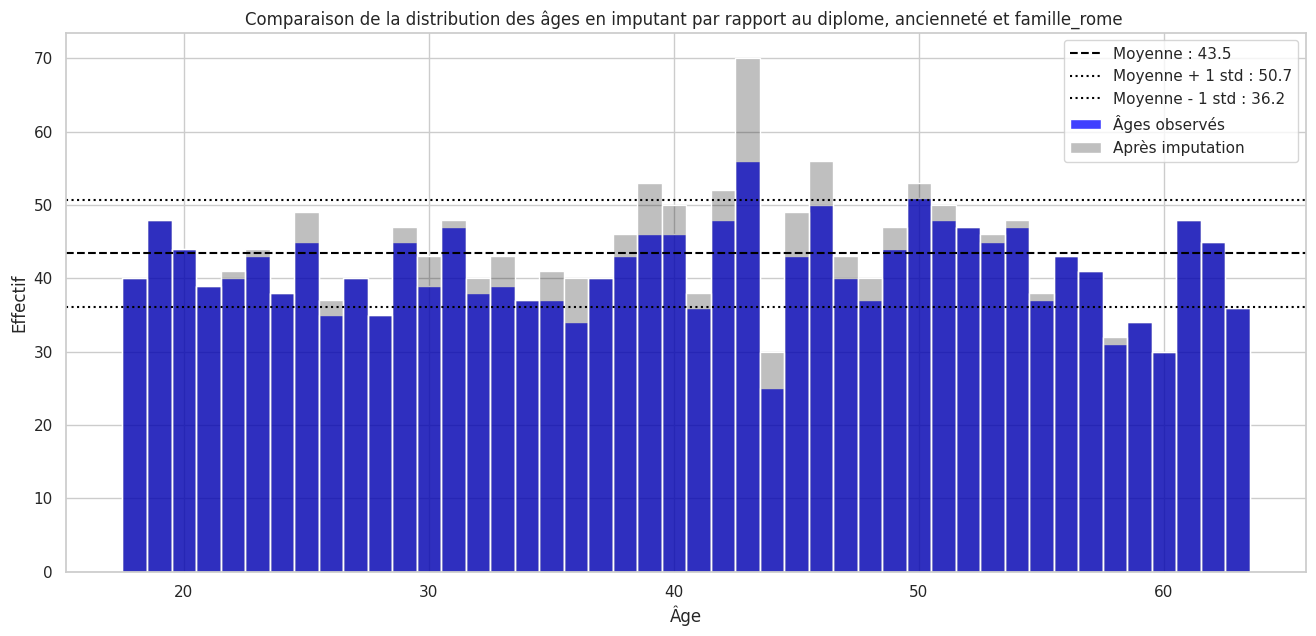

,age,age_impute2,niveau_diplome,famille_rome,tranche_anciennete


NaN après Imputation : 0


In [12]:
# Création de la feature 'famille_rome'
df_age["famille_rome"] = (
    df_age["code_rome_vise"]
    .astype("string")
    .str[0]
)

# Recopie des données
df_age["age_impute2"] = df_age["age"]

# Calcul de la médian par rapport au groupement niveau de diplome, tranche_anciennete et famille_rome
mediane_groupe_2 = df_age.groupby(
    [
       "niveau_diplome",
        "tranche_anciennete",
        "famille_rome"
    ],
    dropna=False,
    observed=True 
)["age"].transform(
    lambda serie: serie.quantile(
        0.5,
        interpolation="nearest"
    )
)

# Imputation des ages 'NaN'
df_age["age_impute2"] = df_age["age_impute2"].fillna(
    mediane_groupe_2
)

plt.figure(figsize=(16, 7))

ax = sns.histplot(
    df_age["age"].dropna(),
    color='Blue',
    discrete=True,
    label="Âges observés",
    alpha=0.75
)

sns.histplot(
    df_age["age_impute2"],
    color='Black',
    discrete=True,
    label="Après imputation",
    alpha=0.25
)

# Moyenne des effectifs par modalité
effectifs = (
    df_age["age_impute2"]
    .dropna()
    .value_counts()
)

effectif_moyen = effectifs.mean()
ecart_type = effectifs.std()

ax.axhline(
    effectif_moyen,
    color="black",
    linestyle="--",
    label=f"Moyenne : {effectif_moyen:.1f}"
)

ax.axhline(
    effectif_moyen + ecart_type,
    color="black",
    linestyle=":",
    label=f"Moyenne + 1 std : {effectif_moyen + ecart_type:.1f}"
)

ax.axhline(
    max(0, effectif_moyen - ecart_type),
    color="black",
    linestyle=":",
    label=f"Moyenne - 1 std : {max(0, effectif_moyen - ecart_type):.1f}"
)


plt.title("Comparaison de la distribution des âges en imputant par rapport au diplome, ancienneté et famille_rome ")
plt.xlabel("Âge")
plt.ylabel("Effectif")
plt.legend()
plt.show()

# Etape de verification
masque_age_manquant = df_age["age_impute"].isna()

display(
    df_age.loc[
        masque_age_manquant,
        [
            "age",
            "age_impute2",
            "niveau_diplome",
            "famille_rome",
            "tranche_anciennete"
        ]
    ]
)
print("NaN après Imputation :", df_age["age_impute"].isna().sum())

Nous observons :
- La moyenne a augmentée de **41.3 -> 54.3** (Pour rappel : 43.5 avec uniquement diplome et ancienneté).
- La répartition reste toujours trés présente autour de 41 ans cependant elle est visuellement plus étalée sur les autres âges.
- Il n'y a pas plus de NaN après cette imputation.

Verifions avec un masquage artificiel des données connues et calculons la MAE :

In [13]:
colonnes_groupe = [
    "niveau_diplome",
    "tranche_anciennete",
    "famille_rome",
    "nationalite_hors_ue"
]

# 1	age	float64	46	18.0	63.0
# 2	niveau_diplome	object	4	Non applicable	Non applicable
# 4	code_rome_vise	object	50	A1202	W1401
# 5	code_insee_commune	object	2407	01007	97601
# 6	est_allocataire	float64	2	0.0	1.0
# 7	nationalite_hors_ue	int64	2	0	1
# 8	synthese_entretien	object	9	Non applicable	Non applicable
# 9	classe_retour_emploi


df_age_connu = df_age.loc[
    df_age["age"].notna()
].copy()

# Fonction détaillée dans le fichier eda.py
resultats_validation = validation_mae(df_age_connu, colonnes_groupe, "age")

display(resultats_validation)

#Evaluation de la MAE Moyenne
display (resultats_validation["MAE"].mean())

,seed,MAE,Erreur_mediane,RMSE,age_exact_%,Erreur_de_2_unites_%,Erreur_de_5_unites_%,Erreur_de_10_unites_%
0,0,12.589474,12.0,15.094265,2.368421,11.578947,25.000000,45.526316
1,1,12.902632,12.0,15.438247,1.842105,10.789474,23.947368,42.894737
2,2,12.689474,11.0,15.259854,1.578947,10.789474,23.947368,46.842105
3,3,13.036842,12.0,15.564129,1.052632,9.210526,22.631579,42.631579
4,4,12.931579,12.0,15.624037,2.105263,11.578947,24.473684,45.526316
5,5,12.431579,11.0,15.061278,2.105263,10.789474,25.789474,47.631579
6,6,13.042105,12.0,15.847464,2.105263,8.684211,25.526316,45.526316
7,7,11.668421,10.0,14.198221,2.368421,11.052632,29.736842,51.052632
8,8,12.636842,11.0,15.031896,2.368421,9.210526,23.157895,46.315789
9,9,12.710526,11.5,15.257267,1.315789,10.000000,24.473684,46.578947


np.float64(12.663947368421052)

On observe que l'ajout de la feature `famille_rome` dégrade les résultats MAE passe de 11.53 (uniquement`anciennete_poste_ans`, `niveau_diplome`) à **12.32**. Cette segmentation supplémentaire ne permet donc pas de mieux estimer l’âge. Elle produit probablement des groupes plus petits et moins représentatifs, dont les médianes sont moins robustes.

Face à l’absence d’amélioration apportée par les méthodes d’imputation conditionnelles, il devient pertinent d’évaluer une stratégie plus simple et plus robuste : l’imputation par la médiane globale.

#### 3.3.3 Approche sur l'imputation des données pour l'age à partir de la médiane globale

Calculons directement la MAE d'une approche globale

In [14]:
resultats_mediane_globale = validation_mediane_globale(
    df_age,
    feature_name="age"
)

display(resultats_mediane_globale)
#Evaluation de la MAE Moyenne
display (resultats_mediane_globale["MAE"].mean())

,seed,Mediane_globale,MAE,Erreur_mediane,RMSE,age_exact_%,Erreur_de_2_unites_%,Erreur_de_5_unites_%,Erreur_de_10_unites_%
0,0,40.0,11.123684,11.0,12.850456,3.421053,12.368421,22.894737,46.842105
1,1,41.0,10.802632,11.0,12.619221,1.315789,12.631579,27.368421,49.736842
2,2,41.0,11.344737,11.0,13.284637,1.842105,13.684211,26.842105,47.631579
3,3,41.0,11.700000,12.0,13.486445,2.105263,10.789474,23.157895,44.473684
4,4,41.0,11.557895,12.0,13.364328,2.631579,11.842105,23.157895,45.789474
5,5,41.0,11.702632,11.5,13.426114,1.578947,9.473684,22.894737,45.000000
6,6,41.0,11.655263,11.0,13.460371,1.578947,9.736842,22.894737,47.368421
7,7,41.0,10.886842,10.0,12.806968,3.421053,14.736842,26.315789,52.368421
8,8,41.0,11.497368,11.0,13.352410,2.368421,12.894737,23.947368,46.052632
9,9,41.0,11.563158,12.0,13.325085,1.842105,12.105263,22.894737,44.210526


np.float64(11.38342105263158)

L’évaluation répétée de l’imputation par médiane globale produit une MAE moyenne de **11,38** ans. Cette méthode obtient de meilleurs résultats que les imputations conditionnelles précédemment testées, dont la MAE atteignait 11,53 ans avec niveau_diplome et anciennete_poste_ans, puis 12,32 ans après l’ajout de famille_rome.

#### 3.3.4 Conclusion imputation `age`

Les variables disponibles ne permettent donc pas de reconstituer précisément l’âge réel des demandeurs d’emploi. Cependant, parmi les stratégies évaluées, la médiane globale constitue la solution la plus pertinente : elle est plus simple, plus stable et légèrement plus performante que les méthodes de regroupement. Elle sera donc retenue pour remplacer les valeurs manquantes de la feature age.

Cette imputation crée toutefois une ambiguïté entre un âge réellement égal à la médiane et un âge remplacé artificiellement. Une nouvelle feature binaire `age_manquant` sera donc ajoutée :

- 0 : l’âge était renseigné dans les données initiales ;
- 1 : l’âge était manquant et a été imputé.

Actions préconisées :

| feature | **`Scénario 1`** | **`Scénario 2`** | **`Scénario 3`** | **`Scénario 4`** |
|:---:|:---:|:---:|:---:|:---:|
|`age`|✅ retenue</br>approche médiane + feature `age_manquant`|❌ écartée|❌ écartée|✅ retenue</br>approche médiane + feature `age_manquant`|

###  3.4 Analyse des données - feature `niveau_diplome`

La variable `niveau_diplome` correspond au plus haut niveau de diplôme obtenu par le demandeur d’emploi. Une première observation réalisée lors de l’analyse générale des données, présentée en section 3.1, met en évidence la présence de valeurs manquantes. Une stratégie de traitement doit donc être définie avant l’entraînement des modèles.

La variable contient quatre modalités observées :

- Sans diplôme
- Bac
- Bac+2
- Bac+5

Effectif minimum hors NaN : 366
Diplôme concerné : Bac+5
Effectif maximum hors NaN : 779
Diplôme concerné : Bac
Nombre de valeurs NaN : 68


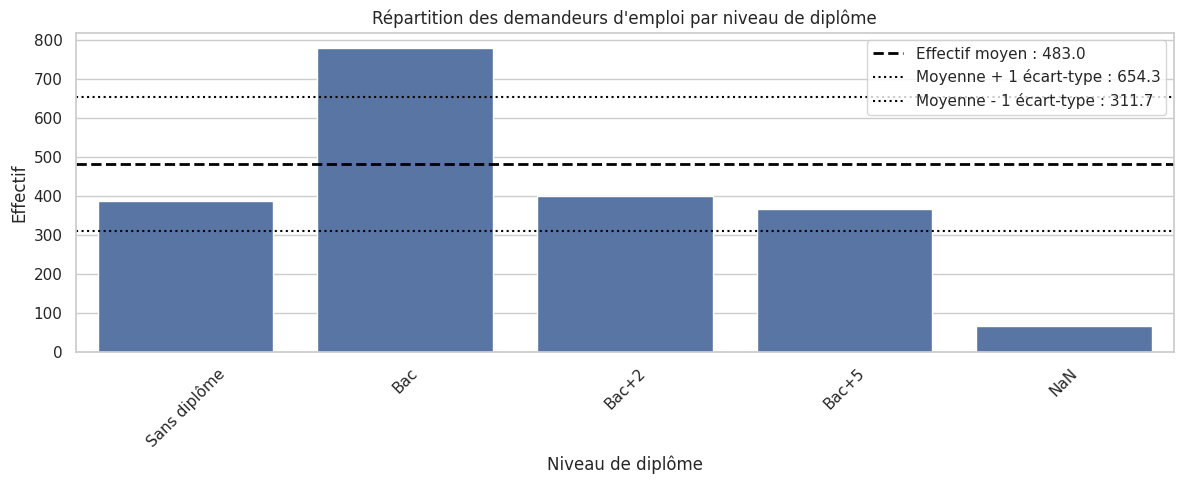

In [15]:
# Transformer les valeurs manquantes en catégorie explicite
diplome_affichage = (
    df_train["niveau_diplome"]
    .fillna("NaN")
    .astype(str)
)

# Ordre d'affichage des catégories
ordre = [
    "Sans diplôme",
    "Bac",
    "Bac+2",
    "Bac+5",
    "NaN"
]

# Conserver uniquement les modalités réellement présentes
ordre = [
    diplome
    for diplome in ordre
    if diplome in diplome_affichage.unique()
]

# Effectif de chaque niveau de diplôme, NaN compris
effectifs = (
    diplome_affichage
    .value_counts()
    .reindex(ordre, fill_value=0)
)

# Exclure NaN du calcul des statistiques
effectifs_sans_nan = effectifs.drop(
    index="NaN",
    errors="ignore"
)

# Moyenne et écart-type des effectifs par modalité
effectif_moyen = effectifs_sans_nan.mean()
ecart_type = effectifs_sans_nan.std(ddof=0)

plt.figure(figsize=(12, 5))

ax = sns.countplot(
    x=diplome_affichage,
    order=ordre
)

# Effectif moyen
ax.axhline(
    y=effectif_moyen,
    color="black",
    linestyle="--",
    linewidth=2,
    label=f"Effectif moyen : {effectif_moyen:.1f}"
)

# Effectif moyen + un écart-type
ax.axhline(
    y=effectif_moyen + ecart_type,
    color="black",
    linestyle=":",
    label=(
        "Moyenne + 1 écart-type : "
        f"{effectif_moyen + ecart_type:.1f}"
    )
)

# Effectif moyen - un écart-type
ax.axhline(
    y=max(0, effectif_moyen - ecart_type),
    color="black",
    linestyle=":",
    label=(
        "Moyenne - 1 écart-type : "
        f"{max(0, effectif_moyen - ecart_type):.1f}"
    )
)

print(
    "Effectif minimum hors NaN :",
    effectifs_sans_nan.min()
)
print(
    "Diplôme concerné :",
    effectifs_sans_nan.idxmin()
)

print(
    "Effectif maximum hors NaN :",
    effectifs_sans_nan.max()
)
print(
    "Diplôme concerné :",
    effectifs_sans_nan.idxmax()
)

print(
    "Nombre de valeurs NaN :",
    effectifs.get("NaN", 0)
)

plt.title(
    "Répartition des demandeurs d'emploi "
    "par niveau de diplôme"
)
plt.xlabel("Niveau de diplôme")
plt.ylabel("Effectif")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

L’analyse de la distribution sur le jeu d’entraînement montre que la catégorie `Bac` est la plus représentée, avec **779 observations**, tandis que la catégorie `Bac+5` est la moins représentée, avec **366 observations**. La distribution est donc modérément déséquilibrée en faveur de la modalité `Bac`.

Par ailleurs, **68 valeurs sont manquantes** dans le jeu d’entraînement. Ces valeurs ne peuvent pas être attribuées de manière fiable à l’une des quatre catégories existantes. Une imputation par la modalité majoritaire, par exemple Bac, augmenterait artificiellement la représentation de cette catégorie et reviendrait à attribuer un diplôme sans justification factuelle.

Les valeurs manquantes seront donc remplacées par une modalité spécifique : `Non renseigné`

Cette stratégie conserve explicitement l’information relative à l’absence de réponse, sans introduire d’hypothèse non vérifiable sur le niveau réel de diplôme du demandeur d’emploi.

Contrairement à la feature `age`, il n’est pas nécessaire de créer une variable binaire supplémentaire telle que `niveau_diplome_manquant`. La modalité `Non renseigné` joue déjà ce rôle et permet au modèle d’identifier directement les observations pour lesquelles le diplôme était absent. La stratégie retenue consiste à conserver la feature `niveau_diplome` et à remplacer les valeurs manquantes par la modalité `Non renseigné`. Cette approche évite d’attribuer arbitrairement un diplôme aux demandeurs d’emploi et préserve l’information portée par l’absence de réponse.

Actions préconisées :

| feature | **`Scénario 1`** | **`Scénario 2`** | **`Scénario 3`** | **`Scénario 4`** |
|:---:|:---:|:---:|:---:|:---:|
|`niveau_diplome`|✅ retenue</br>imputation avec Modalité `Non renseigné`|❌ écartée|❌ écartée|✅ retenue</br>imputation avec Modalité `Non renseigné` |

N.B : Dans le **Scénario 2 - éthique**, `niveau_diplome` peut être conservée : elle ne constitue pas une catégorie particulière de données au sens de l’article 9 du RGPD. Elle peut néanmoins refléter certaines inégalités sociales ou produire des effets indirectement discriminatoires. Son utilisation devra donc être justifiée par sa pertinence métier et accompagnée d’une analyse des performances et des erreurs selon les différents niveaux de diplôme.

###  3.5 Analyse des données - feature `anciennete_poste_ans`

La variable `anciennete_poste_ans` ne contient aucune valeur manquante. Aucun traitement d’imputation n’est donc nécessaire. L’analyse portera uniquement sur sa distribution et sur la vérification des valeurs atypiques détectées par la méthode de l’IQR.

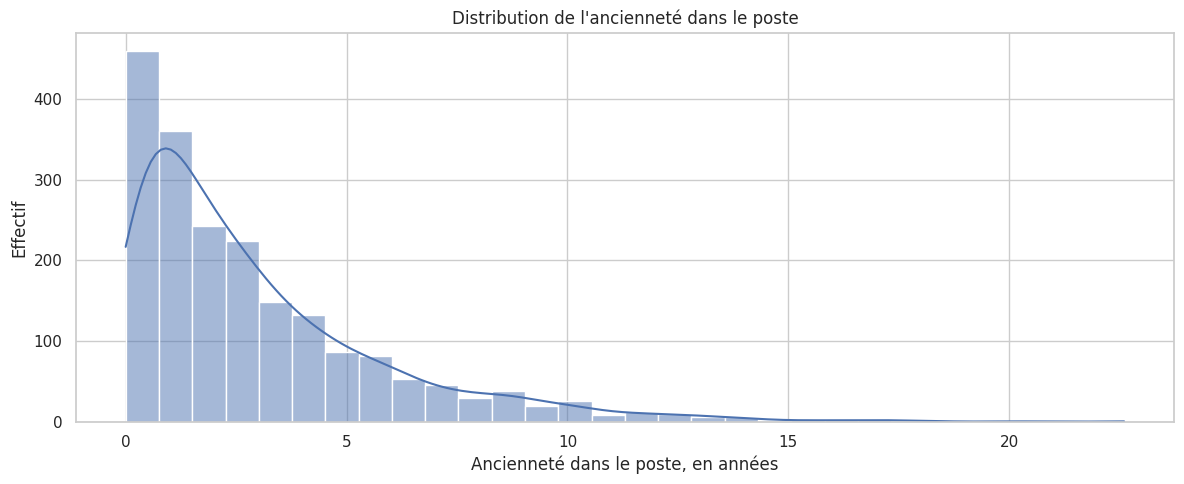

In [16]:
# Ce code utilise un histogramme plutôt qu’un countplot, car anciennete_poste_ans est une variable quantitative continue
# comportant 154 valeurs distinctes. Afficher une barre pour chaque valeur exacte rendrait le graphique très chargé et difficile à interpréter.
plt.figure(figsize=(12, 5))

# Représentation de la distribution de l'ancienneté
sns.histplot(
    data=df_train,

    # Variable quantitative étudiée
    x="anciennete_poste_ans",

    # Regroupement des valeurs dans 30 intervalles.
    # Cela permet d'obtenir une représentation plus lisible
    # que l'affichage d'une barre pour chacune des 154 valeurs.
    bins=30,

    # Ajout d'une estimation lissée de la densité.
    # Cette courbe aide à visualiser la forme générale
    # de la distribution et son asymétrie.
    kde=True
)

# Titre du graphique
plt.title(
    "Distribution de l'ancienneté dans le poste"
)

# Libellé de l'axe horizontal
plt.xlabel(
    "Ancienneté dans le poste, en années"
)

# Libellé de l'axe vertical
plt.ylabel("Effectif")

# Ajustement automatique des marges
# afin d'éviter que les titres soient coupés
plt.tight_layout()

# Affichage du graphique
plt.show()

La variable `anciennete_poste_ans` ne contient aucune valeur manquante et ne nécessite donc aucune imputation. Sa distribution est fortement asymétrique à droite : les faibles anciennetés sont majoritaires et les effectifs diminuent progressivement lorsque l’ancienneté augmente. La valeur la plus fréquente est de **0,2 an**, observée pour **75 demandeurs d’emploi**, tandis que l’ancienneté maximale atteint **22,6 ans**.

La méthode de l’IQR (calculé sur tout le dataset) identifie **126 observations** supérieures à environ **9,05 ans** comme atypiques. Ces valeurs restent toutefois réalistes au regard du contexte métier. Elles sont donc considérées comme des valeurs extrêmes plausibles et sont conservées dans le dataset. Aucun traitement correctif n’est appliqué à cette feature.

Actions préconisées :

| feature | **`Scénario 1`** | **`Scénario 2`** | **`Scénario 3`** | **`Scénario 4`** |
|:---:|:---:|:---:|:---:|:---:|
|`anciennete_poste_ans`|✅ retenue|✅ retenue|❌ écartée|✅ retenue|

###  3.6 Analyse des données - feature `code_rome_vise`

La variable `code_rome_vise` correspond au code du métier visé par le demandeur d’emploi. Malgré la présence de chiffres, il s’agit d’une variable catégorielle nominale et non d’une variable numérique. A noter qu'il y a **aucune valeur manquante** et que le dataset fait état de **50 codes différents**.

Nombre de valeurs manquantes : 0
Nombre de codes ROME différents : 50
Effectif moyen par code : 40.0
Effectif minimum : 21
Code concerné : W1401
Effectif maximum : 56
Code concerné : H1206


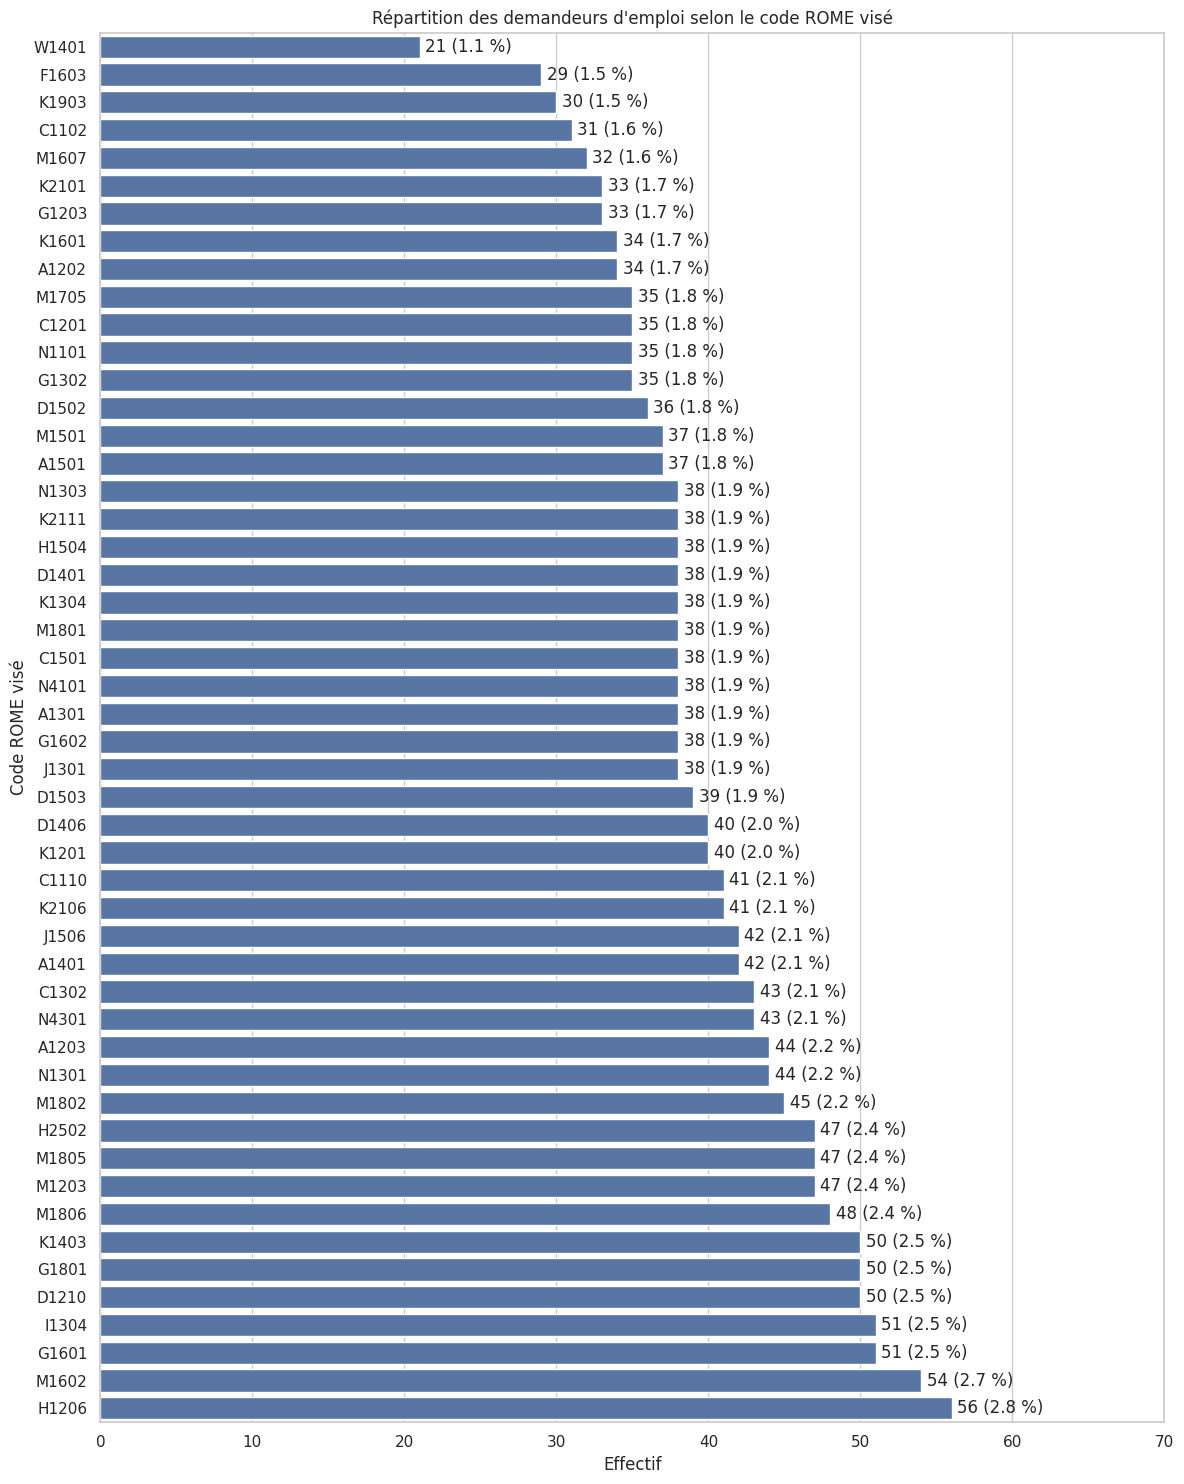

In [17]:
# Préparation de la série sans modifier le DataFrame initial
code_rome_affichage = (
    df_train["code_rome_vise"]
    .astype("string")
    .str.strip()
    .str.upper()
)

# Effectif par code ROME
effectifs = (
    code_rome_affichage
    .value_counts()
    .sort_values()
)

print(
    "Nombre de valeurs manquantes :",
    code_rome_affichage.isna().sum()
)

print(
    "Nombre de codes ROME différents :",
    code_rome_affichage.nunique()
)

print(
    "Effectif moyen par code :",
    round(effectifs.mean(), 2)
)

print(
    "Effectif minimum :",
    effectifs.min()
)

print(
    "Code concerné :",
    effectifs.idxmin()
)

print(
    "Effectif maximum :",
    effectifs.max()
)

print(
    "Code concerné :",
    effectifs.idxmax()
)

# Effectifs classés du moins fréquent au plus fréquent
ordre = effectifs.index

plt.figure(figsize=(12, 15))

ax = sns.countplot(
    data=df_train,
    y="code_rome_vise",
    order=ordre
)

total = len(df_train)

# Affichage de l'effectif et du pourcentage
for barre in ax.patches:
    effectif = int(barre.get_width())
    pourcentage = effectif / total * 100

    ax.annotate(
        f"{effectif} ({pourcentage:.1f} %)",
        (
            effectif,
            barre.get_y() + barre.get_height() / 2
        ),
        ha="left",
        va="center",
        xytext=(4, 0),
        textcoords="offset points"
    )

ax.set_xlim(
    0,
    effectifs.max() * 1.25
)

plt.title(
    "Répartition des demandeurs d'emploi "
    "selon le code ROME visé"
)
plt.xlabel("Effectif")
plt.ylabel("Code ROME visé")
plt.tight_layout()
plt.show()

Le tableau montre que les effectifs varient de **21 à 56 observations par code**, ce qui indique une distribution suffisamment équilibrée et ne justifie pas de regroupement des catégories rares. La variable est donc conservée sous sa forme complète.

Actions préconisées :

| feature | **`Scénario 1`** | **`Scénario 2`** | **`Scénario 3`** | **`Scénario 4`** |
|:---:|:---:|:---:|:---:|:---:|
|`code_rome_vise`|✅ retenue|✅ retenue|❌ écartée|❌ écartée|

N.B : La stratégie principale consiste à conserver le code complet et à utiliser un One-Hot Encoding, le paramètre handle_unknown="ignore" permet de traiter un éventuel code présent dans de nouvelles données, mais absent du jeu d’entraînement.

###  3.7 Analyse des données - feature `code_insee_commune`

###  3.8 Analyse des données - feature `est_allocataire`
###  3.19 Analyse des données - feature `nationalite_hors_ue`
###  3.10 Analyse des données - feature `synthese_entretien`
###  3.11 Analyse des données - feature `classe_retour_emploi`
###  3.12 📝 Synthèse de l'exploration des données

| feature | **`Scénario 1`** | **`Scénario 2`** | **`Scénario 3`** | **`Scénario 4`** |
|:---:|:---:|:---:|:---:|:---:|
|`usager_id`|❌ écartée|❌ écartée|❌ écartée|❌ écartée|
|`age`|✅ retenue</br>approche médiane + feature `age_manquant`|❌ écartée|❌ écartée|✅ retenue</br>approche médiane + feature `age_manquant`|
|`niveau_diplome`|✅ retenue</br>imputation avec Modalité `Non renseigné`|❌ écartée|❌ écartée|✅ retenue</br>imputation avec Modalité `Non renseigné` |
|`anciennete_poste_ans`|✅ retenue|✅ retenue|❌ écartée|✅ retenue|
|`code_rome_vise`|✅ retenue|✅ retenue|❌ écartée|❌ écartée|